Name: James Fisher
Date: April 17, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 8, Store Sales Time Series ETS and ARIMA models

In [22]:
# Load libraries
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

# Load data
data_path = Path('./data/store-sales-time-series')
train = pd.read_csv(data_path / 'train.csv', parse_dates=['date'])
test = pd.read_csv(data_path / 'test.csv', parse_dates=['date'])
holidays = pd.read_csv(data_path / 'holidays_events.csv', parse_dates=['date'])
oil = pd.read_csv(data_path / 'oil.csv', parse_dates=['date'])
stores = pd.read_csv(data_path / 'stores.csv')
transactions = pd.read_csv(data_path / 'transactions.csv', parse_dates=['date'])

print(train.shape, test.shape, holidays.shape, oil.shape, stores.shape, transactions.shape)
train.head()

(3000888, 6) (28512, 5) (350, 6) (1218, 2) (54, 5) (83488, 3)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [23]:
# Data overview
print('Train date range:', train['date'].min().date(), 'to', train['date'].max().date())
print('Test date range: ', test['date'].min().date(), 'to', test['date'].max().date())
print('Number of stores:', train['store_nbr'].nunique())
print('Number of families:', train['family'].nunique())
print('Forecast horizon:', test['date'].nunique(), 'days')
print('Families:')
print(sorted(train['family'].unique()))

Train date range: 2013-01-01 to 2017-08-15
Test date range:  2017-08-16 to 2017-08-31
Number of stores: 54
Number of families: 33
Forecast horizon: 16 days
Families:
['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


In [24]:
# Aggregate sales by date and family
family_daily = (
    train.groupby(['date', 'family'], as_index=False)['sales']
    .sum()
    .sort_values(['family', 'date'])
)

family_pivot = family_daily.pivot(index='date', columns='family', values='sales').sort_index()
family_pivot.head()

family,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,EGGS,FROZEN FOODS,GROCERY I,GROCERY II,HARDWARE,HOME AND KITCHEN I,HOME AND KITCHEN II,HOME APPLIANCES,HOME CARE,LADIESWEAR,LAWN AND GARDEN,LINGERIE,"LIQUOR,WINE,BEER",MAGAZINES,MEATS,PERSONAL CARE,PET SUPPLIES,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,2.0,810.0,0.0,180.58900,0.0,186.0,143.0,71.09000,46.0,29.654999,700.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,5.0,105.0,0.0,110.801000,25.0,0.0,0.0,42.637000,37.847000,0.0,0.0,0.000000
2013-01-02,255.0,0.0,207.0,72092.0,0.0,26246.31900,0.0,74629.0,23381.0,15754.50000,10932.0,7115.388000,202020.0,1476.0,46.0,0.0,0.0,21.0,0.0,0.0,121.0,469.0,2411.0,0.0,20871.464028,17204.0,0.0,0.0,13975.884938,5338.111976,0.0,0.0,1526.750002
2013-01-03,161.0,0.0,125.0,52105.0,0.0,18456.48002,0.0,55893.0,18001.0,11172.45500,7358.0,4760.805009,144878.0,1048.0,37.0,0.0,0.0,15.0,0.0,0.0,83.0,366.0,2476.0,0.0,16597.398113,12568.0,0.0,0.0,10674.393983,3591.388005,0.0,0.0,1094.310994
2013-01-04,169.0,0.0,133.0,54167.0,0.0,16721.96901,0.0,52064.0,18148.0,10143.20900,6760.0,4525.934004,135754.0,1031.0,57.0,0.0,0.0,13.0,0.0,0.0,127.0,382.0,4796.0,0.0,21625.963055,11303.0,0.0,0.0,10772.515038,4472.965990,0.0,0.0,1293.120995
2013-01-05,342.0,0.0,191.0,77818.0,0.0,22367.76108,0.0,70128.0,23082.0,13734.94501,8576.0,5781.605010,188356.0,1273.0,87.0,0.0,0.0,11.0,0.0,0.0,180.0,458.0,6715.0,0.0,20879.091050,16819.0,0.0,0.0,13475.009055,5830.073020,0.0,0.0,1245.637004


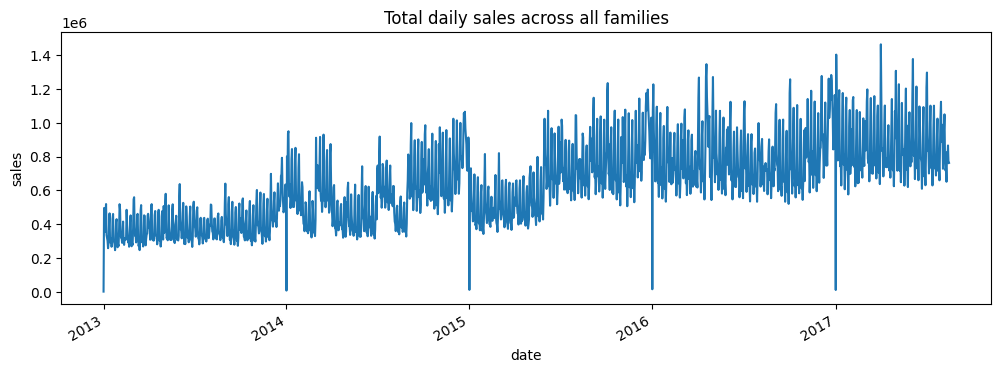

In [25]:
# Plot total daily sales across all families
ax = family_pivot.sum(axis=1).plot(title='Total daily sales across all families')
ax.set_ylabel('sales')
plt.show()

In [26]:
# Hold out last 16 days of training data as validation
HORIZON = test['date'].nunique()
assert HORIZON == 16, 'Expected Kaggle test horizon to be 16 days.'

train_end = family_pivot.index.max() - pd.Timedelta(days=HORIZON)
train_ts = family_pivot.loc[:train_end]
valid_ts = family_pivot.loc[train_end + pd.Timedelta(days=1):]

print('Training window:', train_ts.index.min().date(), 'to', train_ts.index.max().date())
print('Validation window:', valid_ts.index.min().date(), 'to', valid_ts.index.max().date())
print('Validation shape:', valid_ts.shape)

Training window: 2013-01-01 to 2017-07-30
Validation window: 2017-07-31 to 2017-08-15
Validation shape: (16, 33)


In [27]:
# Helper functions
# Define seasonal period (weekly seasonality)
SEASONAL_PERIODS = 7

# Define RMSLE metric
def rmsle(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true), 0, None)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Define forecasting functions
def fit_ets_forecast(series, horizon=16):
    y = np.log1p(series.astype(float)).replace([np.inf, -np.inf], np.nan).dropna()

    candidate_specs = [
        {"trend": "add", "damped_trend": True,  "seasonal": "add", "seasonal_periods": SEASONAL_PERIODS},
        {"trend": "add", "damped_trend": False, "seasonal": "add", "seasonal_periods": SEASONAL_PERIODS},
        {"trend": None,  "damped_trend": False, "seasonal": "add", "seasonal_periods": SEASONAL_PERIODS},
        {"trend": "add", "damped_trend": False, "seasonal": None,  "seasonal_periods": None},
        {"trend": None,  "damped_trend": False, "seasonal": None,  "seasonal_periods": None},
    ]

    last_error = None

    for spec in candidate_specs:
        try:
            model = ExponentialSmoothing(
                y,
                trend=spec["trend"],
                damped_trend=spec["damped_trend"],
                seasonal=spec["seasonal"],
                seasonal_periods=spec["seasonal_periods"],
                initialization_method="estimated",
            )
            res = model.fit(optimized=True, use_brute=True, remove_bias=True)
            pred_log = res.forecast(horizon)

            pred = np.expm1(pred_log)
            pred = np.asarray(pred, dtype=float)

            if not np.isfinite(pred).all():
                raise ValueError("ETS forecast contains non-finite values")

            pred = np.clip(pred, 0, None)

            pred_index = pd.date_range(
                series.index.max() + pd.Timedelta(days=1),
                periods=horizon,
                freq="D"
            )
            return res, pd.Series(pred, index=pred_index)

        except Exception as e:
            last_error = e
            continue

    raise ValueError(f"All ETS specifications failed. Last error: {last_error}")

# ARIMA forecasting function
def fit_arima_forecast(series, horizon=16):
    y = np.log1p(series.astype(float))
    model = SARIMAX(
        y,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, SEASONAL_PERIODS),
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    pred_log = res.forecast(horizon)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)
    return res, pd.Series(pred, index=pd.date_range(series.index.max() + pd.Timedelta(days=1), periods=horizon, freq='D'))

# Define stationarity checks
def stationarity_checks(series):
    y = np.log1p(series.astype(float))
    out = {}
    try:
        out['adf_pvalue'] = adfuller(y.dropna(), autolag='AIC')[1]
    except Exception:
        out['adf_pvalue'] = np.nan
    try:
        out['kpss_pvalue'] = kpss(y.dropna(), regression='c', nlags='auto')[1]
    except Exception:
        out['kpss_pvalue'] = np.nan
    return out

# Define residual diagnostics
def residual_diagnostics(residuals, lags=14):
    resid = pd.Series(residuals).dropna()
    diag = {}
    try:
        diag['ljungbox_pvalue'] = float(acorr_ljungbox(resid, lags=[lags], return_df=True)['lb_pvalue'].iloc[0])
    except Exception:
        diag['ljungbox_pvalue'] = np.nan
    try:
        diag['jarque_bera_pvalue'] = float(jarque_bera(resid)[1])
    except Exception:
        diag['jarque_bera_pvalue'] = np.nan
    diag['resid_mean'] = float(resid.mean()) if len(resid) else np.nan
    diag['resid_std'] = float(resid.std()) if len(resid) else np.nan
    return diag

In [28]:
# Modeling step

# Filter warnings
warnings.filterwarnings('default')

# Loop through each family, fit ETS and ARIMA models, evaluate on validation set, and collect diagnostics
families = list(train_ts.columns)

validation_rows = []
ets_validation_forecasts = {}
arima_validation_forecasts = {}
model_objects = {}

for family in families:
    series_train = train_ts[family].asfreq('D')
    series_valid = valid_ts[family].asfreq('D')

    stats = stationarity_checks(series_train)

    # ETS
    try:
        ets_res, ets_fcst = fit_ets_forecast(series_train, horizon=HORIZON)
        ets_score = rmsle(series_valid.values, ets_fcst.values)
        ets_diag = residual_diagnostics(ets_res.resid)
        ets_validation_forecasts[family] = ets_fcst
        model_objects[(family, 'ETS')] = ets_res
    except Exception as e:
        ets_score = np.nan
        ets_diag = {'ljungbox_pvalue': np.nan, 'jarque_bera_pvalue': np.nan, 'resid_mean': np.nan, 'resid_std': np.nan}
        print(f'ETS failed for {family}: {repr(e)}')

    # ARIMA
    try:
        arima_res, arima_fcst = fit_arima_forecast(series_train, horizon=HORIZON)
        arima_score = rmsle(series_valid.values, arima_fcst.values)
        arima_diag = residual_diagnostics(arima_res.resid)
        arima_validation_forecasts[family] = arima_fcst
        model_objects[(family, 'ARIMA')] = arima_res
    except Exception as e:
        arima_score = np.nan
        arima_diag = {'ljungbox_pvalue': np.nan, 'jarque_bera_pvalue': np.nan, 'resid_mean': np.nan, 'resid_std': np.nan}
        print(f'ARIMA failed for {family}: {e}')

    validation_rows.append({
        'family': family,
        'adf_pvalue_train_log': stats['adf_pvalue'],
        'kpss_pvalue_train_log': stats['kpss_pvalue'],
        'ets_rmsle': ets_score,
        'ets_ljungbox_pvalue': ets_diag['ljungbox_pvalue'],
        'ets_jarque_bera_pvalue': ets_diag['jarque_bera_pvalue'],
        'arima_rmsle': arima_score,
        'arima_ljungbox_pvalue': arima_diag['ljungbox_pvalue'],
        'arima_jarque_bera_pvalue': arima_diag['jarque_bera_pvalue'],
    })

# Compile validation results into a DataFrame
validation_results = pd.DataFrame(validation_rows).sort_values('family').reset_index(drop=True)
validation_results.head()

C:\Users\unkno\AppData\Local\Temp\ipykernel_12528\1330061624.py:85: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  out['kpss_pvalue'] = kpss(y.dropna(), regression='c', nlags='auto')[1]
c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In 

,family,adf_pvalue_train_log,kpss_pvalue_train_log,ets_rmsle,ets_ljungbox_pvalue,ets_jarque_bera_pvalue,arima_rmsle,arima_ljungbox_pvalue,arima_jarque_bera_pvalue
0,AUTOMOTIVE,0.024196,0.01,0.160761,6.287928e-01,0.0,0.176817,2.665170e-27,0.0
1,BABY CARE,0.091536,0.01,0.444270,4.984156e-03,0.0,0.445975,1.987899e-02,0.0
2,BEAUTY,0.220196,0.01,0.283729,1.984303e-08,0.0,0.288845,3.200070e-07,0.0
3,BEVERAGES,0.099463,0.01,0.141384,5.379155e-01,0.0,0.138399,1.913926e-61,0.0
4,BOOKS,0.295740,0.01,0.432701,6.201467e-05,0.0,0.424711,2.684278e-04,0.0


In [29]:
# Compare models and summarize results
validation_results['better_model'] = np.where(
    validation_results['ets_rmsle'] <= validation_results['arima_rmsle'],
    'ETS',
    'ARIMA'
)

# Create summary table
summary_table = pd.DataFrame({
    'metric': ['mean RMSLE', 'median RMSLE', 'families where model won'],
    'ETS': [
        validation_results['ets_rmsle'].mean(),
        validation_results['ets_rmsle'].median(),
        int((validation_results['better_model'] == 'ETS').sum())
    ],
    'ARIMA': [
        validation_results['arima_rmsle'].mean(),
        validation_results['arima_rmsle'].median(),
        int((validation_results['better_model'] == 'ARIMA').sum())
    ]
})

# Display
summary_table

,metric,ETS,ARIMA
0,mean RMSLE,0.236565,0.217394
1,median RMSLE,0.185608,0.143984
2,families where model won,11.000000,22.000000


In [30]:
# Show top 10 families where ETS performed best
validation_results.sort_values('ets_rmsle').head(10)

,family,adf_pvalue_train_log,kpss_pvalue_train_log,ets_rmsle,ets_ljungbox_pvalue,ets_jarque_bera_pvalue,arima_rmsle,arima_ljungbox_pvalue,arima_jarque_bera_pvalue,better_model
29,PREPARED FOODS,1.758016e-03,0.01,0.081488,9.566557e-01,0.0,0.076598,1.003827e-43,0.0,ARIMA
5,BREAD/BAKERY,1.934143e-01,0.01,0.088714,8.144742e-01,0.0,0.084799,9.121711e-29,0.0,ARIMA
10,EGGS,9.808127e-02,0.01,0.105143,2.157678e-01,0.0,0.099124,6.926535e-39,0.0,ARIMA
24,MEATS,2.109329e-09,0.01,0.105635,4.559939e-01,0.0,0.101617,2.328769e-48,0.0,ARIMA
30,PRODUCE,8.155979e-03,0.01,0.106006,6.819546e-36,0.0,0.077338,1.821920e-07,0.0,ARIMA
20,LAWN AND GARDEN,8.778757e-01,0.01,0.107572,8.114121e-05,0.0,0.124963,1.547113e-19,0.0,ETS
11,FROZEN FOODS,3.985422e-07,0.01,0.114335,2.062713e-13,0.0,0.103388,1.442176e-42,0.0,ARIMA
8,DAIRY,2.260571e-01,0.01,0.114713,1.600573e-01,0.0,0.101724,3.603215e-57,0.0,ARIMA
28,POULTRY,9.873703e-02,0.01,0.118622,8.288271e-03,0.0,0.111183,1.602337e-48,0.0,ARIMA
6,CELEBRATION,1.529504e-02,0.01,0.126905,1.205042e-01,0.0,0.116109,9.823033e-01,0.0,ARIMA


In [31]:
# Show top 10 families where ARIMA performed best
validation_results.sort_values('arima_rmsle').head(10)

,family,adf_pvalue_train_log,kpss_pvalue_train_log,ets_rmsle,ets_ljungbox_pvalue,ets_jarque_bera_pvalue,arima_rmsle,arima_ljungbox_pvalue,arima_jarque_bera_pvalue,better_model
29,PREPARED FOODS,1.758016e-03,0.01,0.081488,9.566557e-01,0.0,0.076598,1.003827e-43,0.0,ARIMA
30,PRODUCE,8.155979e-03,0.01,0.106006,6.819546e-36,0.0,0.077338,1.821920e-07,0.0,ARIMA
5,BREAD/BAKERY,1.934143e-01,0.01,0.088714,8.144742e-01,0.0,0.084799,9.121711e-29,0.0,ARIMA
10,EGGS,9.808127e-02,0.01,0.105143,2.157678e-01,0.0,0.099124,6.926535e-39,0.0,ARIMA
24,MEATS,2.109329e-09,0.01,0.105635,4.559939e-01,0.0,0.101617,2.328769e-48,0.0,ARIMA
8,DAIRY,2.260571e-01,0.01,0.114713,1.600573e-01,0.0,0.101724,3.603215e-57,0.0,ARIMA
11,FROZEN FOODS,3.985422e-07,0.01,0.114335,2.062713e-13,0.0,0.103388,1.442176e-42,0.0,ARIMA
27,PLAYERS AND ELECTRONICS,1.267650e-02,0.01,0.229419,2.020938e-01,0.0,0.103639,9.995714e-01,0.0,ARIMA
32,SEAFOOD,1.288667e-05,0.01,0.128630,7.920710e-01,0.0,0.108707,1.220166e-03,0.0,ARIMA
28,POULTRY,9.873703e-02,0.01,0.118622,8.288271e-03,0.0,0.111183,1.602337e-48,0.0,ARIMA


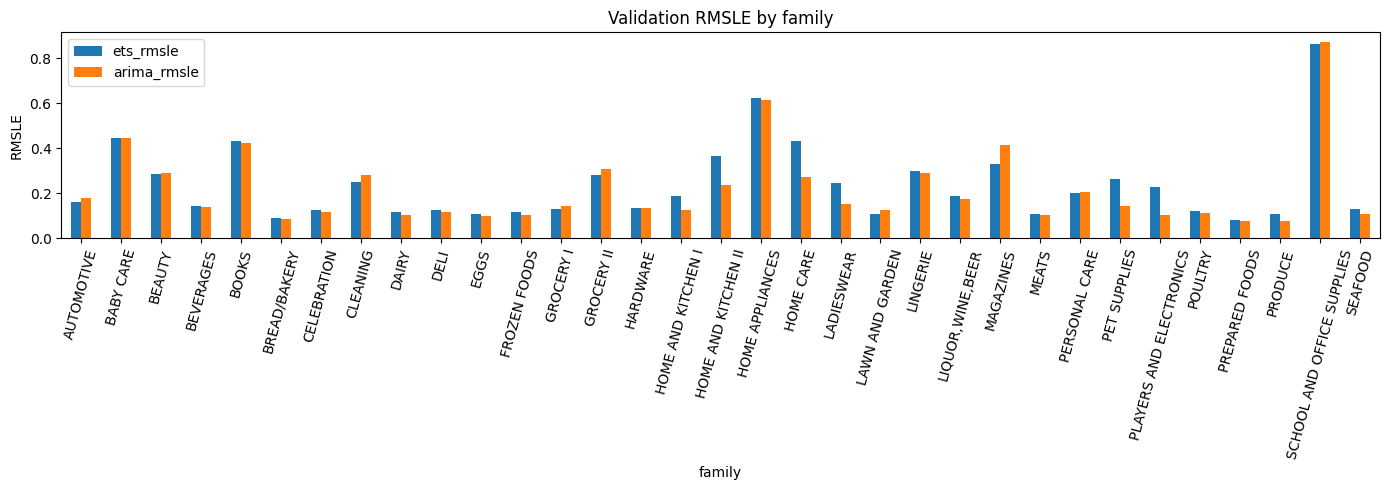

In [32]:
# Plot comparison of ETS vs ARIMA RMSLE by family
ax = validation_results.set_index('family')[['ets_rmsle', 'arima_rmsle']].plot(kind='bar', figsize=(14, 5), title='Validation RMSLE by family')
ax.set_ylabel('RMSLE')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [33]:
# Show diagnostic statistics for all families
diagnostic_cols = [
    'family',
    'adf_pvalue_train_log',
    'kpss_pvalue_train_log',
    'ets_ljungbox_pvalue',
    'ets_jarque_bera_pvalue',
    'arima_ljungbox_pvalue',
    'arima_jarque_bera_pvalue',
    'better_model'
]
validation_results[diagnostic_cols].sort_values('family')


,family,adf_pvalue_train_log,kpss_pvalue_train_log,ets_ljungbox_pvalue,ets_jarque_bera_pvalue,arima_ljungbox_pvalue,arima_jarque_bera_pvalue,better_model
0,AUTOMOTIVE,2.419593e-02,0.01,6.287928e-01,0.0,2.665170e-27,0.0,ETS
1,BABY CARE,9.153642e-02,0.01,4.984156e-03,0.0,1.987899e-02,0.0,ETS
2,BEAUTY,2.201964e-01,0.01,1.984303e-08,0.0,3.200070e-07,0.0,ETS
3,BEVERAGES,9.946275e-02,0.01,5.379155e-01,0.0,1.913926e-61,0.0,ARIMA
4,BOOKS,2.957399e-01,0.01,6.201467e-05,0.0,2.684278e-04,0.0,ARIMA
5,BREAD/BAKERY,1.934143e-01,0.01,8.144742e-01,0.0,9.121711e-29,0.0,ARIMA
6,CELEBRATION,1.529504e-02,0.01,1.205042e-01,0.0,9.823033e-01,0.0,ARIMA
7,CLEANING,4.300614e-03,0.01,8.275571e-05,0.0,3.008891e-53,0.0,ETS
8,DAIRY,2.260571e-01,0.01,1.600573e-01,0.0,3.603215e-57,0.0,ARIMA
9,DELI,1.069597e-01,0.01,8.297365e-02,0.0,1.716587e-51,0.0,ARIMA


In [34]:
# Show families with residual autocorrelation concerns
print('Families with ETS residual autocorrelation concerns (Ljung-Box p < 0.05):')
display(validation_results.loc[validation_results['ets_ljungbox_pvalue'] < 0.05, ['family', 'ets_ljungbox_pvalue', 'ets_rmsle']].sort_values('ets_ljungbox_pvalue'))

# Show families with residual autocorrelation concerns
print('Families with ARIMA residual autocorrelation concerns (Ljung-Box p < 0.05):')
display(validation_results.loc[validation_results['arima_ljungbox_pvalue'] < 0.05, ['family', 'arima_ljungbox_pvalue', 'arima_rmsle']].sort_values('arima_ljungbox_pvalue'))


Families with ETS residual autocorrelation concerns (Ljung-Box p < 0.05):


,family,ets_ljungbox_pvalue,ets_rmsle
30,PRODUCE,6.819546e-36,0.106006
22,"LIQUOR,WINE,BEER",3.069812e-16,0.187861
25,PERSONAL CARE,4.871873e-15,0.200366
11,FROZEN FOODS,2.062713e-13,0.114335
31,SCHOOL AND OFFICE SUPPLIES,1.618484e-09,0.865904
2,BEAUTY,1.984303e-08,0.283729
12,GROCERY I,3.906950e-07,0.131124
19,LADIESWEAR,1.369438e-05,0.245040
4,BOOKS,6.201467e-05,0.432701
20,LAWN AND GARDEN,8.114121e-05,0.107572


Families with ARIMA residual autocorrelation concerns (Ljung-Box p < 0.05):


,family,arima_ljungbox_pvalue,arima_rmsle
12,GROCERY I,6.766626e-63,0.143984
3,BEVERAGES,1.913926e-61,0.138399
8,DAIRY,3.603215e-57,0.101724
7,CLEANING,3.008891e-53,0.282408
9,DELI,1.716587e-51,0.117799
28,POULTRY,1.602337e-48,0.111183
24,MEATS,2.328769e-48,0.101617
29,PREPARED FOODS,1.003827e-43,0.076598
11,FROZEN FOODS,1.442176e-42,0.103388
10,EGGS,6.926535e-39,0.099124


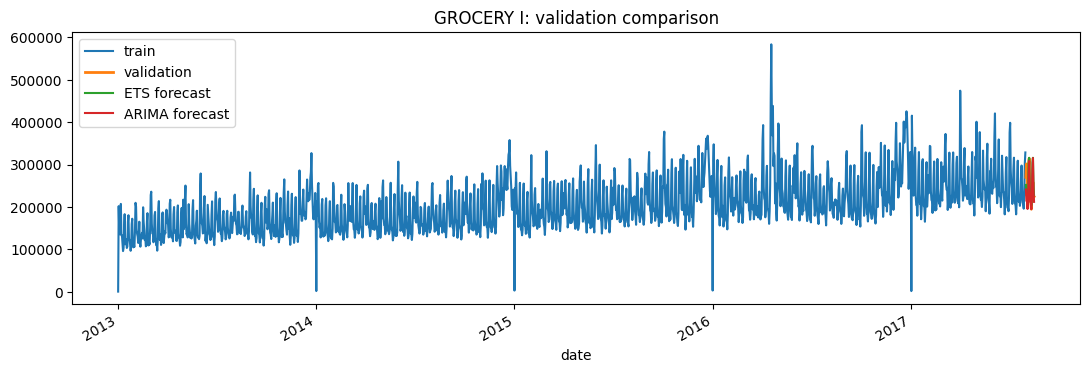

In [35]:
# Plot example family forecasts vs actuals
example_family = 'GROCERY I'

fig, ax = plt.subplots(figsize=(13, 4))
train_ts[example_family].plot(ax=ax, label='train')
valid_ts[example_family].plot(ax=ax, label='validation', linewidth=2)
ets_validation_forecasts[example_family].plot(ax=ax, label='ETS forecast')
arima_validation_forecasts[example_family].plot(ax=ax, label='ARIMA forecast')
ax.set_title(f'{example_family}: validation comparison')
ax.legend()
plt.show()

In [36]:
# Generate forecasts for test set using the best model for each family
full_family_ts = family_pivot.asfreq('D')
future_dates = pd.date_range(test['date'].min(), test['date'].max(), freq='D')

# Loop through each family, fit the best model on the full training data, and generate forecasts for the test horizon
ets_family_forecasts = {}
arima_family_forecasts = {}

for family in full_family_ts.columns:
    series = full_family_ts[family]

    try:
        ets_res, ets_fcst = fit_ets_forecast(series, horizon=HORIZON)
        ets_family_forecasts[family] = ets_fcst.values
    except Exception as e:
        print(f"Full-data ETS failed for {family}: {repr(e)}")
        ets_family_forecasts[family] = np.repeat(np.nan, HORIZON)

    try:
        arima_res, arima_fcst = fit_arima_forecast(series, horizon=HORIZON)
        arima_family_forecasts[family] = arima_fcst.values
    except Exception as e:
        print(f"Full-data ARIMA failed for {family}: {repr(e)}")
        arima_family_forecasts[family] = np.repeat(np.nan, HORIZON)

# Convert forecasts to DataFrames for easier handling
ets_family_forecasts = pd.DataFrame(ets_family_forecasts, index=future_dates)
arima_family_forecasts = pd.DataFrame(arima_family_forecasts, index=future_dates)

# Display ETS forecasts for the test horizon
ets_family_forecasts.head()


c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associat

,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,EGGS,FROZEN FOODS,GROCERY I,GROCERY II,HARDWARE,HOME AND KITCHEN I,HOME AND KITCHEN II,HOME APPLIANCES,HOME CARE,LADIESWEAR,LAWN AND GARDEN,LINGERIE,"LIQUOR,WINE,BEER",MAGAZINES,MEATS,PERSONAL CARE,PET SUPPLIES,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD
2017-08-16,329.232586,7.223800,304.566898,154711.705681,0.100392,27269.953460,623.504057,62429.362869,44886.900999,14281.707574,8955.957821,5553.885265,229355.027688,1420.330455,68.985296,1572.441229,1464.289049,3.197319,13792.468013,505.685003,878.505873,378.554581,4077.280001,436.882024,16972.099631,14988.616811,368.098215,579.000601,17341.747448,4669.050318,150049.340962,2660.825008,940.968097
2017-08-17,333.233747,6.007107,269.635348,140248.903107,0.095740,23882.943921,711.295822,57561.331057,35676.005005,13077.727323,7782.342543,5315.715554,205029.612119,1330.384091,63.196080,1607.142831,1330.512805,2.890214,13509.299300,441.698978,714.290199,366.590155,5216.423317,448.025328,18763.110418,12848.909031,358.331507,564.904079,15215.441202,4272.044194,91480.678207,2615.379575,777.364059
2017-08-18,363.597660,6.654566,290.020532,170538.338050,0.103477,27468.281220,773.537562,64450.444909,42433.652870,18681.800279,9644.796057,7713.095670,232607.348849,1564.021578,70.216614,1686.311448,1355.616423,3.069447,13524.077690,468.351663,1010.760968,399.758207,8711.364416,511.398845,28072.177561,14502.033279,385.614886,602.618781,28009.122677,4854.231615,111381.098781,2524.009615,1303.360127
2017-08-19,504.450952,7.782275,446.659559,216853.073029,0.130366,32657.708178,862.796882,81361.214351,53173.430063,19699.461177,11351.336216,9617.552247,297116.559303,1873.362220,85.506716,1790.031995,1488.882936,4.663389,14268.195714,728.927911,1116.353867,493.979579,9978.271697,589.938059,21167.733530,20988.962254,466.891171,716.216682,23031.304636,5594.725198,128478.355636,3148.556907,1227.950261
2017-08-20,523.330702,8.538813,522.501669,241594.431045,0.107993,38288.175991,642.626465,82581.233907,59888.731282,21572.686163,13364.954981,7231.258709,311766.674902,1819.734144,95.199627,1869.641892,1545.955883,4.907888,15090.218930,758.008729,903.646969,481.188542,4550.835352,571.287322,21533.210102,23278.200433,460.233314,717.416832,24640.676105,5610.171417,151038.756848,3753.406678,1306.965169


In [37]:
# Disaggregate family forecasts to store-family level using recent sales shares
ALLOC_DAYS = 28

# Calculate recent sales shares by store-family based on the last ALLOC_DAYS of training data
allocation_start = train['date'].max() - pd.Timedelta(days=ALLOC_DAYS - 1)
recent = train.loc[train['date'] >= allocation_start].copy()

# Aggregate recent sales by store-family
store_family_recent = (
    recent.groupby(['store_nbr', 'family'], as_index=False)['sales']
    .sum()
    .rename(columns={'sales': 'recent_sales'})
)

# Calculate total recent sales by family to compute shares
family_recent_totals = (
    store_family_recent.groupby('family', as_index=False)['recent_sales']
    .sum()
    .rename(columns={'recent_sales': 'family_recent_sales'})
)

# Merge to compute shares
store_family_shares = store_family_recent.merge(family_recent_totals, on='family', how='left')
store_family_shares['share'] = np.where(
    store_family_shares['family_recent_sales'] > 0,
    store_family_shares['recent_sales'] / store_family_shares['family_recent_sales'],
    0.0
)

# Safety fallback: if any family somehow has zero recent sales, use equal shares across stores observed for that family in test.
family_store_counts = test.groupby('family')['store_nbr'].nunique().rename('n_stores').reset_index()
store_family_shares = store_family_shares.merge(family_store_counts, on='family', how='right')
store_family_shares['share'] = np.where(
    store_family_shares['share'].isna(),
    1 / store_family_shares['n_stores'],
    store_family_shares['share']
)
store_family_shares = store_family_shares[['store_nbr', 'family', 'share']]
store_family_shares.head()


,store_nbr,family,share
0,1,AUTOMOTIVE,0.012742
1,2,AUTOMOTIVE,0.018706
2,3,AUTOMOTIVE,0.030002
3,4,AUTOMOTIVE,0.011205
4,5,AUTOMOTIVE,0.015453


In [38]:
# Build submission DataFrame by merging forecasts with shares and applying to test set
def build_submission(test_df, family_forecasts_df, shares_df):
    long_fcst = (
        family_forecasts_df.stack()
        .rename('family_forecast')
        .reset_index()
        .rename(columns={'level_0': 'date', 'level_1': 'family'})
    )

    submission = test_df.merge(long_fcst, on=['date', 'family'], how='left')
    submission = submission.merge(shares_df, on=['store_nbr', 'family'], how='left')
    submission['sales'] = submission['family_forecast'] * submission['share']
    submission['sales'] = submission['sales'].fillna(0.0).clip(lower=0)
    return submission[['id', 'sales']].sort_values('id').reset_index(drop=True)

submission_ets = build_submission(test, ets_family_forecasts, store_family_shares)
submission_arima = build_submission(test, arima_family_forecasts, store_family_shares)

submission_ets.head(), submission_arima.head()


(        id        sales
 0  3000888     4.194993
 1  3000889     0.000000
 2  3000890     3.064783
 3  3000891  1652.181311
 4  3000892     0.004563,
         id        sales
 0  3000888     4.428284
 1  3000889     0.000000
 2  3000890     3.053893
 3  3000891  1681.097135
 4  3000892     0.003764)

In [39]:
# Save submission files
submission_ets.to_csv('data/outputs/submission_ets.csv', index=False)
submission_arima.to_csv('data/outputs/submission_arima.csv', index=False)